# 01 — PINN Basics: Teaching a Neural Network to Obey Physics

Welcome! This is the **first** notebook of a hands-on series on **Physics-Informed Neural Networks (PINNs)**.
The series goes from *"I have never seen this before"* to *"I can explain a business use-case on a whiteboard"*.

We start here with the **simplest possible example** so that nothing is hidden. By the end of this
notebook you will be able to:

1. Say **what a PINN is** and how it differs from a normal neural network.
2. Understand the **one trick** that makes it work: *automatic differentiation of the network with respect to its input*.
3. Read and write a **physics loss** (also called the *residual*).
4. Train a PINN to solve a differential equation **without a single training data point** — using only the physics.

> **The energy-company angle.** Energy systems (heat flow in pipes, temperature of a battery,
> pressure in a reservoir, voltage in a circuit) are described by *differential equations* coming from
> physics. PINNs let us blend those known equations with real sensor data. We build up to that. Today we
> just learn the machinery on a toy problem you can check by hand.

## 1. The problem we will solve — exponential decay

We use the most classic differential equation in all of engineering. It shows up as:

- a **capacitor discharging** through a resistor (an *RC circuit*),
- a **hot object cooling down** (Newton's law of cooling),
- **radioactive decay**, a battery self-discharging, a chemical reacting away...

All of these obey the same rule: *the rate of change is proportional to how much you currently have.*

$$\frac{dy}{dt} = -k\,y, \qquad y(0) = y_0$$

- $y(t)$ is the quantity (charge, temperature above ambient, amount of material...).
- $k > 0$ is the **decay rate** — bigger $k$ means faster decay.
- $y(0)=y_0$ is the **initial condition**: where we start.

**We are lucky:** this equation has a known *exact* answer, so we can check whether the PINN is right:

$$y(t) = y_0\, e^{-k t}$$

We will *pretend we don't know this formula*, solve it with a PINN, and then compare against it at the end.

## 2. What is a PINN? The big picture

A **normal neural network** for regression learns a function by looking at many `(input, output)` examples
and minimizing the error on those examples. It needs **data**.

A **PINN** is the same kind of network, but instead of (or in addition to) data, it is told:
*"Your output must satisfy this differential equation."* The differential equation itself becomes the
teacher. This is powerful because in engineering we very often **know the equation** but have **little data**.

Here is the whole idea in one picture. We run a cell below that draws it, but read this first:

```
                 t  ──►  ┌─────────────────────┐  ──►  y_pred(t)
   (a time value)        │   Neural network     │       (predicted value)
                         │   y = NN(t; weights) │
                         └─────────────────────┘
                                   │
                                   │  automatic differentiation
                                   ▼
                             dy/dt  (of the SAME network)
                                   │
                                   ▼
              residual  r(t) = dy/dt + k·y     ← should be 0 everywhere if physics holds
                                   │
                                   ▼
   LOSS  =  mean( r(t)² )  over many t     +     ( y(0) − y0 )²
            └── "obey the equation" ──┘          └── "start correctly" ──┘
```

We add only the starting point, because it is the point given by the differential equation,
we don't have any other point and we cannot compute it since we don't have the original
function to compute t_n --> y(t_n)

The network is trained to make the **loss** small. When the loss is ~0, the network *is* a solution of the
differential equation. Notice: **no dataset of `y` values is needed** — the physics supplies the supervision.

## 3. The one trick: differentiate the network, not the data

The term $\frac{dy}{dt}$ in our equation is a **derivative of the network's output with respect to its input** $t$.

Deep-learning libraries already compute derivatives — that is how they train (backpropagation computes the
derivative of the *loss* with respect to the *weights*). PyTorch exposes this general machinery as
`torch.autograd.grad`, and we can point it at *any* input, including $t$.

So we can ask PyTorch: *"give me $\frac{d\,\text{NN}(t)}{dt}$"* exactly (not a finite-difference approximation),
and plug it straight into the physics. That exactness is what makes PINNs elegant. Let's set up the tools.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

# CPU is plenty for these small problems
device = torch.device("cpu")
print("Torch version:", torch.__version__, "| device:", device)

Torch version: 2.10.0+cpu | device: cpu


### A 30-second demo of automatic differentiation

Before the PINN, let's convince ourselves that PyTorch really can differentiate a function of an input.
We compute the derivative of $f(t)=t^3$ at a few points; the exact answer is $f'(t)=3t^2$.

In [9]:
t = torch.linspace(0, 2, 5, requires_grad=True).reshape(-1, 1)  # inputs we want to differentiate w.r.t.
f = t**3                                                        # some function of t

# df/dt via autograd (grad_outputs handles the vector -> we sum contributions)
df_dt = torch.autograd.grad(f, t, grad_outputs=torch.ones_like(f), create_graph=True)[0]

print("t      :", t.detach().flatten().numpy())
print("df/dt  :", df_dt.detach().flatten().numpy(), " (autograd)")
print("3*t^2  :", (3*t**2).detach().flatten().numpy(), " (exact)")

t      : [0.  0.5 1.  1.5 2. ]
df/dt  : [ 0.    0.75  3.    6.75 12.  ]  (autograd)
3*t^2  : [ 0.    0.75  3.    6.75 12.  ]  (exact)


They match. That `torch.autograd.grad(...)` call is the **heart of every PINN** — keep it in mind, we reuse it.

- `create_graph=True` is important: it lets us later take the derivative *of this derivative* (needed for
  second-order equations) and to backpropagate through it during training.
- `grad_outputs=torch.ones_like(f)` is a technical detail for differentiating a whole vector of outputs at once.

## 4. Build the network

The network is deliberately small: input is a single number $t$, output is a single number $y$. In between we
stack a few `Linear` layers with a smooth activation. We use **`tanh`** (not `ReLU`) on purpose:
PINNs need *smooth* derivatives, and `ReLU` has a kink (its second derivative is zero everywhere), which
hurts. `tanh` is smooth and infinitely differentiable.

In [3]:
class MLP(nn.Module):
    # A small fully-connected network: t (1 number) -> y (1 number).
    def __init__(self, hidden=32, n_hidden_layers=3):
        super().__init__()
        layers = [nn.Linear(1, hidden), nn.Tanh()]
        for _ in range(n_hidden_layers - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers += [nn.Linear(hidden, 1)]        # final layer: no activation
        self.net = nn.Sequential(*layers)

    def forward(self, t):
        return self.net(t)

model = MLP().to(device)
print(model)
print("Trainable parameters:", sum(p.numel() for p in model.parameters()))

MLP(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=32, bias=True)
    (5): Tanh()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)
Trainable parameters: 2209


## 5. Define the physics — the residual

We now encode the equation $\frac{dy}{dt} = -k\,y$. Rearranged so that a correct solution gives **zero**:

$$r(t) \;=\; \frac{dy}{dt} + k\,y \;\;\stackrel{!}{=}\; 0$$

`r(t)` is called the **residual**: it measures *how badly the equation is violated* at time $t$. A perfect
solution has `r(t) = 0` at every `t`. The function below computes it for the current network.

In [4]:
k = 1.5      # decay rate
y0 = 2.0     # initial value y(0)
T = 4.0      # we solve on the time window t in [0, T]

def physics_residual(t):
    # r(t) = dy/dt + k*y  for the current model.
    y = model(t)
    dy_dt = torch.autograd.grad(
        y, t, grad_outputs=torch.ones_like(y), create_graph=True
    )[0]
    return dy_dt + k * y

## 6. Collocation points — where we *check* the physics

We cannot check the equation at *every* instant (there are infinitely many). Instead we sample a finite set of
time points and enforce the physics there. These sampled points are called **collocation points**.

Think of them as *"inspection points"* scattered across the time window. More points = the physics is enforced
more densely. Here we scatter 200 of them randomly in $[0, T]$. We also keep the single **initial point** $t=0$
separately, because that is where we pin the known value $y_0$.

Important: we are not training the neural network to predict the next points in the sequence (like in RNN) or 
anything like that, we are just trying to teach the NN how to approach as much as possible to the original
function, knowing the derivative. For that reason, the train and test will be points in the same interval,
between [0-T] but as they are random, they will be different points.

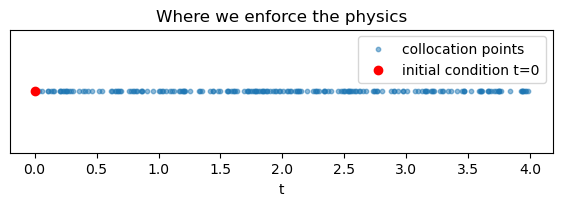

In [5]:
N_coll = 200
t_collocation = torch.rand(N_coll, 1, device=device) * T   # random points in [0, T]
t_collocation.requires_grad_(True)                          # we will differentiate w.r.t. these

t_initial = torch.zeros(1, 1, device=device)               # the point t = 0

# quick look at where the inspection points sit
plt.figure(figsize=(7, 1.6))
plt.scatter(t_collocation.detach().numpy(), np.zeros(N_coll), s=10, alpha=0.5, label="collocation points")
plt.scatter([0], [0], color="red", zorder=5, label="initial condition t=0")
plt.yticks([]); plt.xlabel("t"); plt.title("Where we enforce the physics"); plt.legend(loc="upper right")
plt.show()

## 7. The loss function — turning physics into a number to minimize

Training means making one number (the **loss**) as small as possible. Our loss has **two parts**:

$$
\mathcal{L} \;=\; \underbrace{\frac{1}{N}\sum_i r(t_i)^2}_{\text{physics: obey the equation}}
\;+\; \underbrace{\big(y(0)-y_0\big)^2}_{\text{initial condition: start correctly}}
$$

- The **physics term** pushes the residual toward 0 at all collocation points → the network learns the *shape*
  of the solution.
- The **initial-condition term** pins down *which* solution (the equation alone has infinitely many; the
  starting value selects one).

Without the initial condition the network could happily learn $y(t)=0$ everywhere (which satisfies the equation
but is the wrong solution). This is a key intuition: **physics gives the shape, boundary/initial conditions
select the specific answer.**

In [6]:
def compute_loss():
    # 1) physics residual on collocation points
    r = physics_residual(t_collocation)
    loss_physics = torch.mean(r**2)

    # 2) initial condition y(0) = y0
    y_at_0 = model(t_initial)
    loss_ic = torch.mean((y_at_0 - y0)**2)

    return loss_physics + loss_ic, loss_physics, loss_ic

## 8. Train

Standard PyTorch training loop with the Adam optimizer. Every step:
1. compute the loss (physics + initial condition),
2. backpropagate,
3. nudge the weights.

We log the loss so we can watch it fall. This runs in a few seconds on CPU.

In [7]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

n_iterations = 5000
history = []
for it in range(n_iterations + 1):
    optimizer.zero_grad()
    loss, loss_phys, loss_ic = compute_loss()
    loss.backward()
    optimizer.step()
    history.append(loss.item())
    if it % 500 == 0:
        print(f"iter {it:5d} | total {loss.item():.3e} | physics {loss_phys.item():.3e} | init.cond {loss_ic.item():.3e}")

iter     0 | total 4.785e+00 | physics 8.872e-02 | init.cond 4.697e+00


iter   500 | total 5.440e-04 | physics 5.414e-04 | init.cond 2.680e-06


iter  1000 | total 2.370e-04 | physics 2.368e-04 | init.cond 2.153e-07


iter  1500 | total 1.449e-04 | physics 1.448e-04 | init.cond 6.916e-08


iter  2000 | total 8.331e-05 | physics 8.328e-05 | init.cond 2.594e-08


...

iter  3000 | total 1.863e-05 | physics 1.862e-05 | init.cond 3.086e-09


iter  3500 | total 9.523e-05 | physics 8.546e-05 | init.cond 9.774e-06


iter  4000 | total 9.673e-06 | physics 8.918e-06 | init.cond 7.552e-07


iter  4500 | total 9.942e-05 | physics 8.685e-05 | init.cond 1.256e-05


iter  5000 | total 1.606e-06 | physics 1.606e-06 | init.cond 2.507e-11


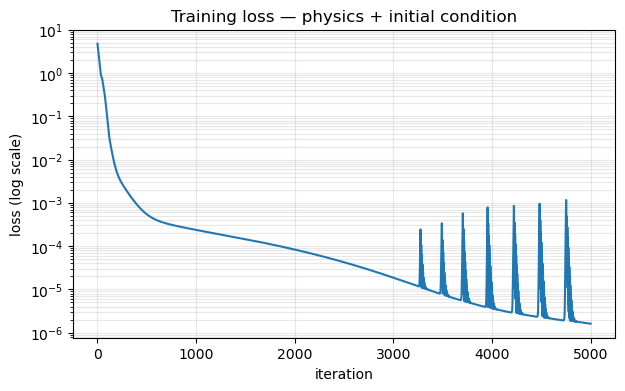

In [8]:
plt.figure(figsize=(7, 4))
plt.semilogy(history)
plt.xlabel("iteration"); plt.ylabel("loss (log scale)")
plt.title("Training loss — physics + initial condition")
plt.grid(True, which="both", alpha=0.3)
plt.show()

## 9. Did it work? Compare against the exact solution

Now we reveal the exact answer $y(t)=y_0 e^{-kt}$ and overlay it on the PINN prediction. Remember: the PINN
**never saw these values** — it only knew the equation and the starting point.

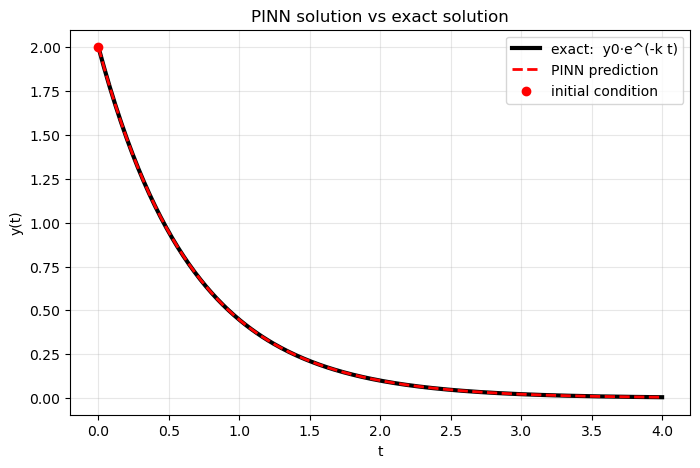

Maximum absolute error over the window: 3.3021e-04


In [ ]:
t_test = torch.linspace(0, T, 300, device=device).reshape(-1, 1) 
# random points in [0, T], so in principle they should be different from the collocation points for training, 
with torch.no_grad():
    y_pinn = model(t_test).cpu().numpy().flatten()

t_np = t_test.cpu().numpy().flatten()
y_exact = y0 * np.exp(-k * t_np)

plt.figure(figsize=(8, 5))
plt.plot(t_np, y_exact, "k-", lw=3, label="exact:  y0·e^(-k t)")
plt.plot(t_np, y_pinn, "r--", lw=2, label="PINN prediction")
plt.scatter([0], [y0], color="red", zorder=5, label="initial condition")
plt.xlabel("t"); plt.ylabel("y(t)")
plt.title("PINN solution vs exact solution")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

max_err = np.max(np.abs(y_pinn - y_exact))
print(f"Maximum absolute error over the window: {max_err:.4e}")

The dashed PINN curve sits right on top of the exact black curve, and the maximum error is tiny — all learned
**from the equation alone**. That is the "aha" moment of PINNs.

## 10. A picture of the whole PINN (schematic)

Let's draw the architecture we just built, so you can reproduce it on a whiteboard in an interview.

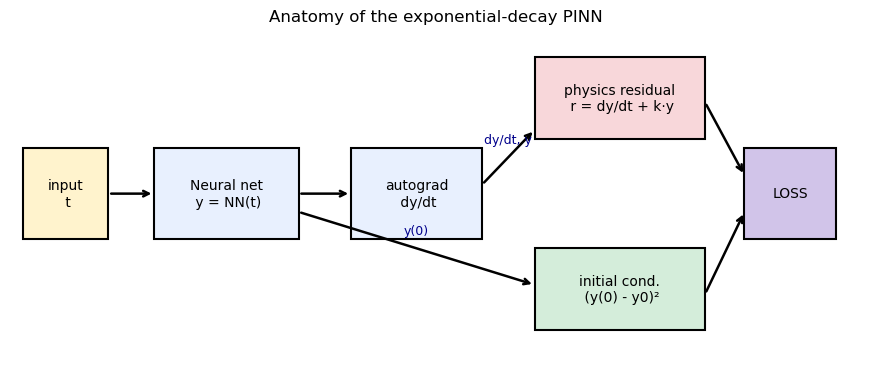

In [10]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.axis("off")

def box(x, y, w, h, text, fc="#e8f0fe"):
    ax.add_patch(plt.Rectangle((x, y), w, h, fc=fc, ec="black", lw=1.5))
    ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=10)

def arrow(x1, y1, x2, y2, text=""):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", lw=1.8))
    if text:
        ax.text((x1+x2)/2, (y1+y2)/2 + 0.15, text, ha="center", fontsize=9, color="darkblue")

box(0.2, 2.0, 1.3, 1.0, "input\n t", fc="#fff3cd")
box(2.2, 2.0, 2.2, 1.0, "Neural net\n y = NN(t)")
box(5.2, 2.0, 2.0, 1.0, "autograd\n dy/dt")
box(8.0, 3.1, 2.6, 0.9, "physics residual\n r = dy/dt + k·y", fc="#f8d7da")
box(8.0, 1.0, 2.6, 0.9, "initial cond.\n (y(0) - y0)²", fc="#d4edda")
box(11.2, 2.0, 1.4, 1.0, "LOSS", fc="#d1c4e9")

arrow(1.5, 2.5, 2.2, 2.5)
arrow(4.4, 2.5, 5.2, 2.5)
arrow(7.2, 2.6, 8.0, 3.2, "dy/dt, y")
arrow(4.4, 2.3, 8.0, 1.5, "y(0)")
arrow(10.6, 3.5, 11.2, 2.7)
arrow(10.6, 1.4, 11.2, 2.3)
ax.set_xlim(0, 13); ax.set_ylim(0.5, 4.3)
ax.set_title("Anatomy of the exponential-decay PINN", fontsize=12)
plt.show()

## 11. Your turn — quick experiments

Try these to build intuition (each is a one-line change + rerun):

1. **Change the physics.** Set `k = 3.0` (faster decay) or `k = 0.5` (slower). Retrain. The PINN adapts with
   no other change — you never had to derive a new formula.
2. **Fewer inspection points.** Set `N_coll = 20`. Does accuracy drop? This shows the role of collocation density.
3. **Break the physics on purpose.** Remove the initial-condition term from `compute_loss` (return only
   `loss_physics`). What solution does it collapse to, and why? (Hint: $y(t)=0$ also satisfies the equation.)
4. **Harder window.** Increase `T = 8.0`. Long horizons are harder for PINNs — a preview of a real challenge.

## 12. Recap — what you now know

- A **PINN** is an ordinary neural network trained to satisfy a **differential equation**, using
  **automatic differentiation** to compute the derivatives that appear in that equation.
- The **residual** measures how badly the equation is violated; the loss squeezes it to zero on a set of
  **collocation points**.
- **Physics gives the shape; initial/boundary conditions select the specific solution.**
- We solved an ODE with **no training data** and matched the exact answer.

**Next notebook (02):** a *second-order* equation — the damped oscillator (springs, RLC circuits, rotating
machinery). We will differentiate *twice*, handle *two* initial conditions, and meet the first real
difficulty PINNs face: oscillations.